<a href="https://colab.research.google.com/github/bikhoa142007-hash/Palmistry/blob/master/Palmistry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')
data_root = '/content/drive/MyDrive/Colab Notebooks/Palmistry Folder'

main_classes = ['đường sinh đạo', 'đường tâm đạo', 'đường trí đạo', 'đường vận mệnh']
sub_classes  = ['dài', 'ngắn', 'trung bình']

for main_cls in main_classes:
    main_path = os.path.join(data_root, main_cls)
    print(f" {main_cls}")
    for sub_cls in sub_classes:
        sub_path = os.path.join(main_path, sub_cls)
        if os.path.isdir(sub_path):
            n = len([f for f in os.listdir(sub_path)
                     if f.lower().endswith(('.jpg','.jpeg','.png'))])
            print(f"   └── {sub_cls}: {n} ảnh")
        else:
            print(f"   └── {sub_cls}: không tìm thấy folder")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 đường sinh đạo
   └── dài: 24 ảnh
   └── ngắn: 33 ảnh
   └── trung bình: 39 ảnh
 đường tâm đạo
   └── dài: 30 ảnh
   └── ngắn: 35 ảnh
   └── trung bình: 30 ảnh
 đường trí đạo
   └── dài: 25 ảnh
   └── ngắn: 40 ảnh
   └── trung bình: 46 ảnh
 đường vận mệnh
   └── dài: 29 ảnh
   └── ngắn: 32 ảnh
   └── trung bình: 31 ảnh


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from PIL import Image
import os, shutil
import glob

In [ ]:
data_root    = '/content/drive/MyDrive/Colab Notebooks/Palmistry Folder'
aug_root     = '/content/drive/MyDrive/Colab Notebooks/Palmistry Folder/Data augment'

input_shape   = (224, 224, 3)
batch_size    = 16
epochs        = 100
learning_rate = 5e-4
n_augment     = 15

main_classes = ['đường sinh đạo', 'đường tâm đạo', 'đường trí đạo', 'đường vận mệnh']
sub_classes  = ['dài', 'ngắn', 'trung bình']

num_main = len(main_classes)
num_sub  = len(sub_classes)

output_names = ['sinh_dao_output', 'tam_dao_output', 'tri_dao_output', 'van_menh_output']

print(f"main classes : {main_classes}")
print(f"sub classes  : {sub_classes}")
print(f"output heads : {output_names}")

main classes : ['đường sinh đạo', 'đường tâm đạo', 'đường trí đạo', 'đường vận mệnh']
sub classes  : ['dài', 'ngắn', 'trung bình']
output heads : ['sinh_dao_output', 'tam_dao_output', 'tri_dao_output', 'van_menh_output']


In [ ]:
img_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest'
)
total_created = 0
for main_idx, main_cls in enumerate(main_classes):
    for sub_idx, sub_cls in enumerate(sub_classes):
        src_dir = os.path.join(data_root, main_cls, sub_cls)
        dst_dir = os.path.join(aug_root,  main_cls, sub_cls)
        os.makedirs(dst_dir, exist_ok=True)

        files = [f for f in os.listdir(src_dir)
                 if os.path.splitext(f)[1].lower() in img_exts]

        print(f"{main_cls}/{sub_cls}: {len(files)} ảnh gốc → tạo thêm {len(files)*n_augment}")

        for fname in files:
            shutil.copy(os.path.join(src_dir, fname), os.path.join(dst_dir, fname))

            img = load_img(os.path.join(src_dir, fname), target_size=(224, 224))
            x   = np.expand_dims(img_to_array(img), axis=0)
            name_no_ext = os.path.splitext(fname)[0]

            count = 0
            for batch in datagen.flow(x, batch_size=1):
                save_name = f"{name_no_ext}_aug{count:03d}.jpg"
                img_aug = tf.keras.preprocessing.image.array_to_img(batch[0])
                img_aug.save(os.path.join(dst_dir, save_name))
                total_created += 1
                count += 1
                if count >= n_augment:
                    break
print(f"Tổng ảnh mới: {total_created}")


đường sinh đạo/dài: 24 ảnh gốc → tạo thêm 360
đường sinh đạo/ngắn: 33 ảnh gốc → tạo thêm 495
đường sinh đạo/trung bình: 39 ảnh gốc → tạo thêm 585
đường tâm đạo/dài: 30 ảnh gốc → tạo thêm 450
đường tâm đạo/ngắn: 35 ảnh gốc → tạo thêm 525
đường tâm đạo/trung bình: 30 ảnh gốc → tạo thêm 450
đường trí đạo/dài: 25 ảnh gốc → tạo thêm 375
đường trí đạo/ngắn: 40 ảnh gốc → tạo thêm 600
đường trí đạo/trung bình: 46 ảnh gốc → tạo thêm 690
đường vận mệnh/dài: 29 ảnh gốc → tạo thêm 435
đường vận mệnh/ngắn: 32 ảnh gốc → tạo thêm 480
đường vận mệnh/trung bình: 31 ảnh gốc → tạo thêm 465
Tổng ảnh mới: 5910


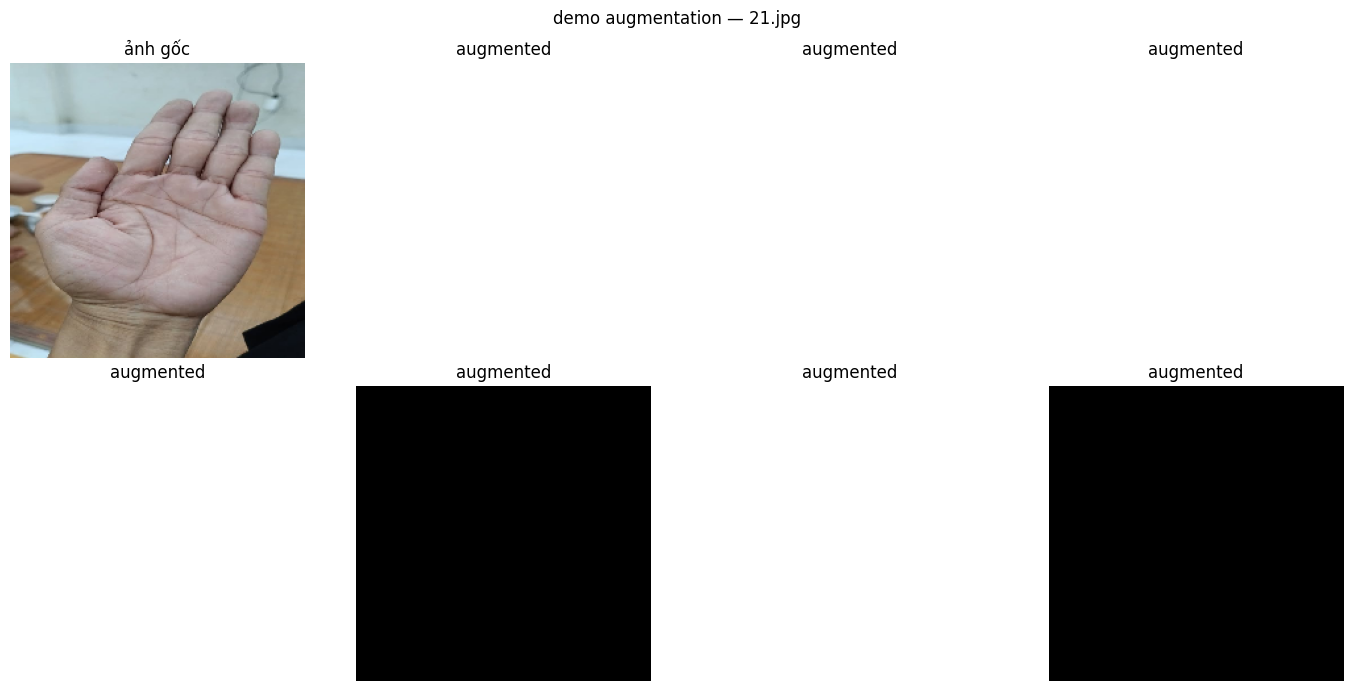

In [ ]:
aug_layer = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
])

sample_dir  = os.path.join(data_root, main_classes[0], sub_classes[0])
sample_file = [f for f in os.listdir(sample_dir)
               if os.path.splitext(f)[1].lower() in img_exts][0]

img = load_img(os.path.join(sample_dir, sample_file), target_size=(224, 224))
x   = np.expand_dims(img_to_array(img), axis=0) / 255.0

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes[0][0].imshow(img)
axes[0][0].set_title('ảnh gốc')
axes[0][0].axis('off')

for ax in axes.flatten()[1:]:
    aug = aug_layer(x, training=True)[0].numpy()
    ax.imshow(np.clip(aug, 0, 1))
    ax.set_title('augmented')
    ax.axis('off')

plt.suptitle(f'demo augmentation — {sample_file}')
plt.tight_layout()
plt.show()

In [ ]:
def scan_files(root, main_classes, sub_classes, img_exts):
    paths, y_main, y_sub = [], [], []

    for main_idx, main_cls in enumerate(main_classes):
        for sub_idx, sub_cls in enumerate(sub_classes):
            folder = os.path.join(root, main_cls, sub_cls)
            if not os.path.isdir(folder):
                print(f"không tìm thấy: {folder}")
                continue

            files = [f for f in os.listdir(folder)
                     if os.path.splitext(f)[1].lower() in img_exts]
            print(f"{main_cls}/{sub_cls}: {len(files)} ảnh")

            for fname in files:
                paths.append(os.path.join(folder, fname))
                y_main.append(main_idx)
                y_sub.append(sub_idx)

    return paths, np.array(y_main, dtype=np.int32), np.array(y_sub, dtype=np.int32)

all_paths, y_main_data, y_sub_data = scan_files(aug_root, main_classes, sub_classes, img_exts)

print(f"Tổng: {len(all_paths)} ảnh")
for i, cls in enumerate(main_classes):
    print(f"  {cls}: {np.sum(y_main_data == i)} ảnh")

đường sinh đạo/dài: 384 ảnh
đường sinh đạo/ngắn: 528 ảnh
đường sinh đạo/trung bình: 624 ảnh
đường tâm đạo/dài: 480 ảnh
đường tâm đạo/ngắn: 560 ảnh
đường tâm đạo/trung bình: 480 ảnh
đường trí đạo/dài: 400 ảnh
đường trí đạo/ngắn: 640 ảnh
đường trí đạo/trung bình: 736 ảnh
đường vận mệnh/dài: 464 ảnh
đường vận mệnh/ngắn: 512 ảnh
đường vận mệnh/trung bình: 496 ảnh
Tổng: 6304 ảnh
  đường sinh đạo: 1536 ảnh
  đường tâm đạo: 1520 ảnh
  đường trí đạo: 1776 ảnh
  đường vận mệnh: 1472 ảnh


In [ ]:
all_paths = np.array(all_paths)

idx_train, idx_val = train_test_split(
    np.arange(len(all_paths)), test_size=0.2,
    random_state=42, stratify=y_main_data
)

paths_train, paths_val   = all_paths[idx_train],   all_paths[idx_val]
ym_train,    ym_val      = y_main_data[idx_train],  y_main_data[idx_val]
ys_train,    ys_val      = y_sub_data[idx_train],   y_sub_data[idx_val]

print(f"train: {len(paths_train)} ảnh | val: {len(paths_val)} ảnh")

def read_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [224, 224])
    img = tf.cast(img, tf.float32) / 255.0
    return img

def build_label_dict(y_main, y_sub):
    n = len(y_main)
    labels = {name: np.zeros(n, dtype=np.int32) for name in output_names}
    weights_dict = {name: np.zeros(n, dtype=np.float32) for name in output_names}
    for i in range(n):
        head = output_names[y_main[i]]
        labels[head][i]       = y_sub[i]
        weights_dict[head][i] = 1.0

    weights = tuple(weights_dict[name] for name in output_names)
    return labels, weights

def make_dataset(paths, y_main, y_sub, batch_size, shuffle=True):
    label_dict, weights = build_label_dict(y_main, y_sub)

    ds = tf.data.Dataset.from_tensor_slices((
        paths,
        label_dict,
        weights
    ))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths))

    ds = ds.map(
        lambda path, labels, w: (read_image(path), labels, w),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(paths_train, ym_train, ys_train, batch_size, shuffle=True)
val_ds   = make_dataset(paths_val,   ym_val,   ys_val,   batch_size, shuffle=False)

print("Dataset (đã áp dụng sample_weight mask cho nhãn thiếu)")


train: 5043 ảnh | val: 1261 ảnh
Dataset (đã áp dụng sample_weight mask cho nhãn thiếu)


In [ ]:
def build_model(input_shape=input_shape, num_sub=num_sub):
    base = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    base.trainable = False

    inputs = layers.Input(shape=input_shape)

    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.1)(x)
    x = layers.RandomZoom(0.1)(x)
    x = layers.RandomBrightness(0.15)(x)

    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.2)(x)

    out_sinh_dao = layers.Dense(num_sub, activation='softmax', name='sinh_dao_output')(x)
    out_tam_dao  = layers.Dense(num_sub, activation='softmax', name='tam_dao_output')(x)
    out_tri_dao  = layers.Dense(num_sub, activation='softmax', name='tri_dao_output')(x)
    out_van_menh = layers.Dense(num_sub, activation='softmax', name='van_menh_output')(x)

    model = Model(
        inputs,
        [out_sinh_dao, out_tam_dao, out_tri_dao, out_van_menh],
        name='MobileNetV2_PalmLine'
    )
    return model

model = build_model()
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "MobileNetV2_PalmLine"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_1       │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation_1   │ (None, 224, 224,  │          0 │ random_flip_1[0]… │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom_1       │ (None, 224, 224,  │          0 │ random_rotation_… │
│ (RandomZoom)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_brightness_1 │ (None, 224, 224,  │          0 │ random_zoom_1[0]… │
│ (RandomBrightness)  │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ random_brightnes… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1280)      │      5,120 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1280)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    327,936 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sinh_dao_output     │ (None, 3)         │        771 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tam_dao_output      │ (None, 3)         │        771 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tri_dao_output      │ (None, 3)         │        771 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ van_menh_output     │ (None, 3)         │        771 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,594,124 (9.90 MB)

 Trainable params: 333,580 (1.27 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate),
    loss={
        'sinh_dao_output': 'sparse_categorical_crossentropy',
        'tam_dao_output' : 'sparse_categorical_crossentropy',
        'tri_dao_output' : 'sparse_categorical_crossentropy',
        'van_menh_output': 'sparse_categorical_crossentropy',
    },
    loss_weights={
        'sinh_dao_output': 1.0,
        'tam_dao_output' : 1.0,
        'tri_dao_output' : 1.0,
        'van_menh_output': 1.0,
    },
    metrics={
        'sinh_dao_output': 'accuracy',
        'tam_dao_output' : 'accuracy',
        'tri_dao_output' : 'accuracy',
        'van_menh_output': 'accuracy',
    }
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=6, restore_best_weights=True, monitor='val_loss'
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        factor=0.5, patience=3, monitor='val_loss', verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/drive/MyDrive/best_palmline_model.keras',
        save_best_only=True, monitor='val_loss', verbose=1
    )
]

print("Compile xong")

Compile xong


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks
)

Epoch 1/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 1.5751 - sinh_dao_output_accuracy: 0.2711 - sinh_dao_output_loss: 0.3715 - tam_dao_output_accuracy: 0.3139 - tam_dao_output_loss: 0.3997 - tri_dao_output_accuracy: 0.2745 - tri_dao_output_loss: 0.4535 - van_menh_output_accuracy: 0.3561 - van_menh_output_loss: 0.3504
Epoch 1: val_loss improved from None to 2.58259, saving model to /content/drive/MyDrive/best_palmline_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_palmline_model.keras
316/316 ━━━━━━━━━━━━━━━━━━━━ 60s 136ms/step - loss: 1.5480 - sinh_dao_output_accuracy: 0.2758 - sinh_dao_output_loss: 0.3727 - tam_dao_output_accuracy: 0.3151 - tam_dao_output_loss: 0.3789 - tri_dao_output_accuracy: 0.2594 - tri_dao_output_loss: 0.4381 - van_menh_output_accuracy: 0.3484 - van_menh_output_loss: 0.3571 - val_loss: 2.5826 - val_sinh_dao_output_accuracy: 0.5107 - val_sinh_dao_output_loss: 0.5925 - val_tam_dao_output_accuracy: 0.4956 - val_tam_dao_output_lo

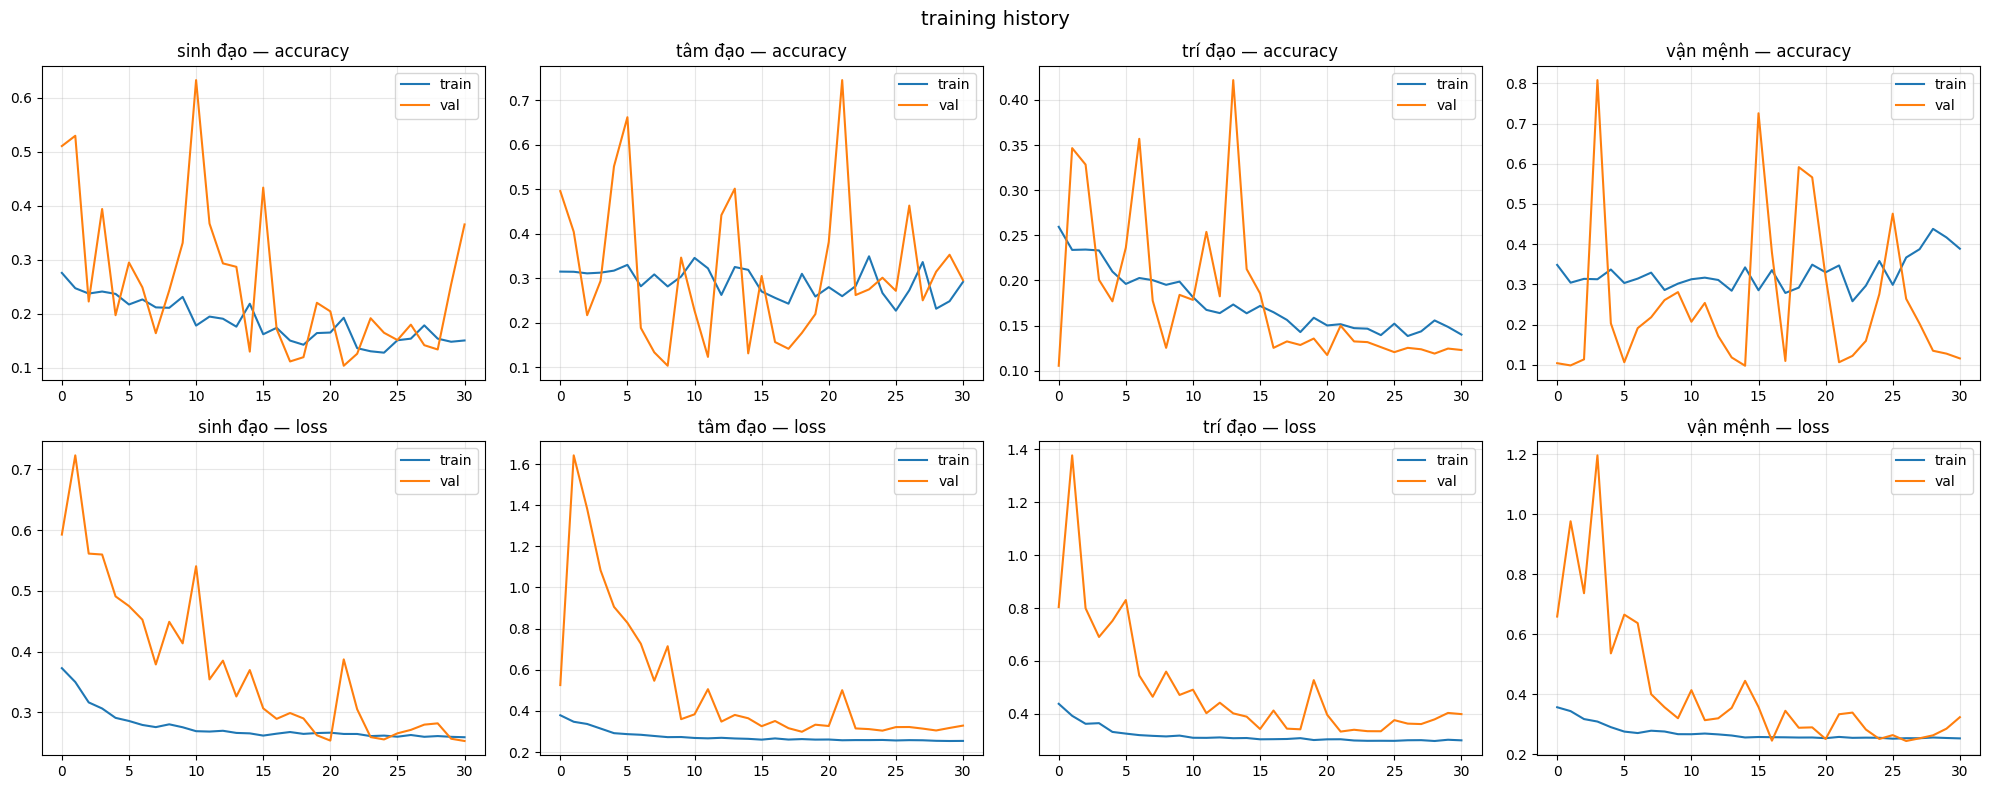

In [ ]:
metrics_to_plot = [
    ('sinh_dao_output_accuracy', 'sinh đạo — accuracy'),
    ('tam_dao_output_accuracy',  'tâm đạo — accuracy'),
    ('tri_dao_output_accuracy',  'trí đạo — accuracy'),
    ('van_menh_output_accuracy', 'vận mệnh — accuracy'),
    ('sinh_dao_output_loss',     'sinh đạo — loss'),
    ('tam_dao_output_loss',      'tâm đạo — loss'),
    ('tri_dao_output_loss',      'trí đạo — loss'),
    ('van_menh_output_loss',     'vận mệnh — loss'),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, (key, title) in zip(axes.flatten(), metrics_to_plot):
    ax.plot(history.history[key],          label='train')
    ax.plot(history.history[f'val_{key}'], label='val')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('training history', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
base_model = model.get_layer('mobilenetv2_1.00_224')
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

trainable_count = sum([np.prod(w.shape) for w in model.trainable_weights])
print(f"trainable params sau fine-tune: {trainable_count:,}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss={
        'sinh_dao_output': 'sparse_categorical_crossentropy',
        'tam_dao_output' : 'sparse_categorical_crossentropy',
        'tri_dao_output' : 'sparse_categorical_crossentropy',
        'van_menh_output': 'sparse_categorical_crossentropy',
    },
    loss_weights={
        'sinh_dao_output': 1.0,
        'tam_dao_output' : 1.0,
        'tri_dao_output' : 1.0,
        'van_menh_output': 1.0,
    },
    metrics={
        'sinh_dao_output': 'accuracy',
        'tam_dao_output' : 'accuracy',
        'tri_dao_output' : 'accuracy',
        'van_menh_output': 'accuracy',
    }
)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

trainable params sau fine-tune: 2,015,116
Epoch 1/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 1.1198 - sinh_dao_output_accuracy: 0.1270 - sinh_dao_output_loss: 0.2768 - tam_dao_output_accuracy: 0.2892 - tam_dao_output_loss: 0.2649 - tri_dao_output_accuracy: 0.1438 - tri_dao_output_loss: 0.3089 - van_menh_output_accuracy: 0.3136 - van_menh_output_loss: 0.2692
Epoch 1: val_loss improved from 1.14534 to 1.07122, saving model to /content/drive/MyDrive/best_palmline_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_palmline_model.keras
316/316 ━━━━━━━━━━━━━━━━━━━━ 57s 138ms/step - loss: 1.1113 - sinh_dao_output_accuracy: 0.1297 - sinh_dao_output_loss: 0.2719 - tam_dao_output_accuracy: 0.2582 - tam_dao_output_loss: 0.2707 - tri_dao_output_accuracy: 0.1465 - tri_dao_output_loss: 0.3097 - van_menh_output_accuracy: 0.3214 - van_menh_output_loss: 0.2585 - val_loss: 1.0712 - val_sinh_dao_output_accuracy: 0.2443 - val_sinh_dao_output_loss: 0.2477 - val_tam_dao_ou